<a href="https://colab.research.google.com/github/Rajdas129/Quant/blob/main/etf%20analysis%20and%20trading%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[*********************100%***********************]  2 of 2 completed


Ticker
QQQ    0.141161
SPY    0.119681
dtype: float64
Ticker
QQQ    0.236782
SPY    0.180131
dtype: float64


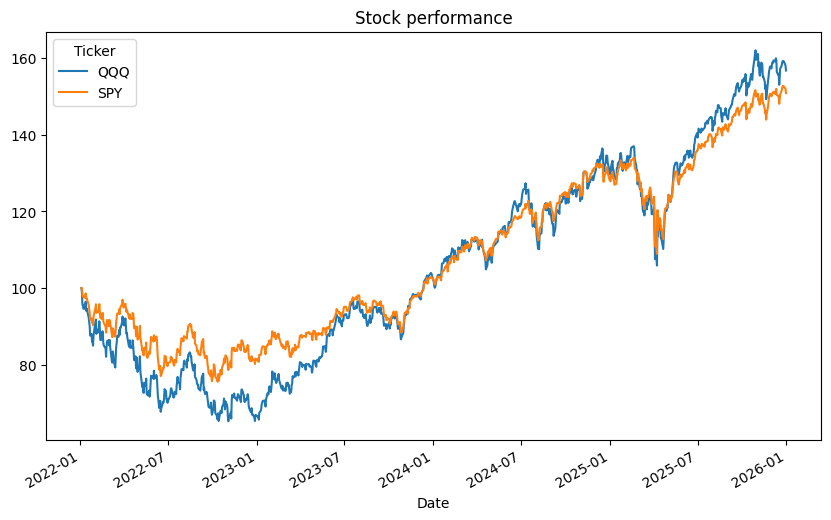

In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
stocks = ['SPY','QQQ']
data=yf.download(stocks, start="2022-01-01",end="2026-01-01",auto_adjust=True)['Close']
normalize=data/data.iloc[0]*100
returns=data.pct_change().dropna()

annual_return=returns.mean()*252
volatility=returns.std()*np.sqrt(252)

print(annual_return)
print(volatility)

normalize.plot(figsize=(10,6),title="Stock performance")
plt.show()

In [6]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

tickers = ["SPY", "QQQ"]
data = yf.download(tickers, start="2015-01-01", end="2025-01-01")["Close"]

returns = data.pct_change().dropna()

correlation = returns.corr()
print(correlation)

/tmp/ipykernel_15818/4263945949.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2015-01-01", end="2025-01-01")["Close"]
[*********************100%***********************]  2 of 2 completed

Ticker       QQQ       SPY
Ticker                    
QQQ     1.000000  0.929276
SPY     0.929276  1.000000


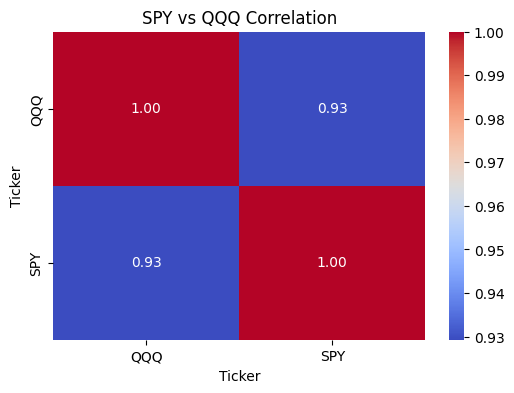

In [7]:
plt.figure(figsize=(6,4))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("SPY vs QQQ Correlation")
plt.show()

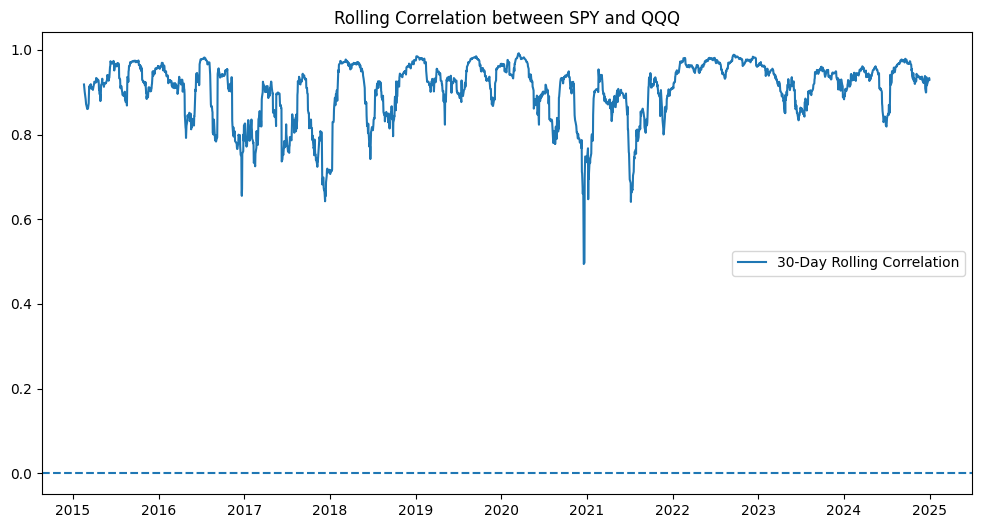

In [8]:
rolling_corr = returns["SPY"].rolling(window=30).corr(returns["QQQ"])
plt.figure(figsize=(12,6))
plt.plot(rolling_corr, label="30-Day Rolling Correlation")
plt.axhline(0, linestyle="--")
plt.title("Rolling Correlation between SPY and QQQ")
plt.legend()
plt.show()

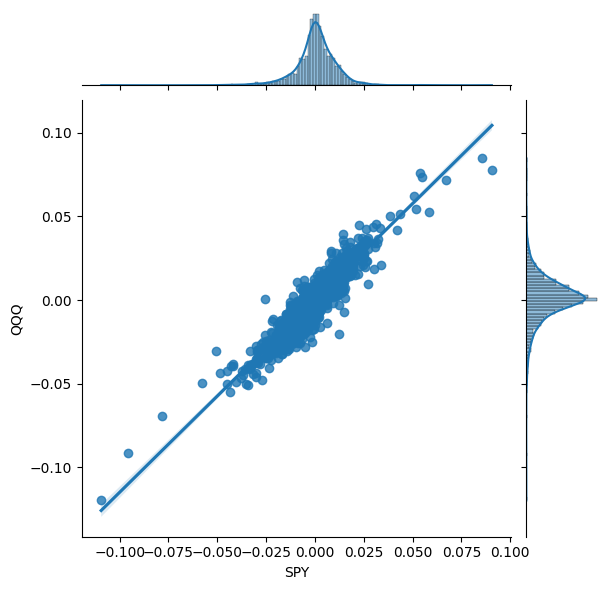

In [9]:
sns.jointplot(x=returns["SPY"], y=returns["QQQ"], kind="reg")

In [10]:
spread = returns["SPY"] - returns["QQQ"]
print(spread)

Date
2015-01-05   -0.003391
2015-01-06    0.003989
2015-01-07   -0.000430
2015-01-08   -0.001394
2015-01-09   -0.001431
                ...   
2024-12-24   -0.002445
2024-12-26    0.000746
2024-12-27    0.002767
2024-12-30    0.001888
2024-12-31    0.004857
Length: 2515, dtype: float64


In [11]:
zscore = (spread - spread.rolling(30).mean()) / spread.rolling(30).std()
print(zscore)

Date
2015-01-05         NaN
2015-01-06         NaN
2015-01-07         NaN
2015-01-08         NaN
2015-01-09         NaN
                ...   
2024-12-24   -0.321094
2024-12-26    0.311886
2024-12-27    0.711467
2024-12-30    0.523152
2024-12-31    1.259306
Length: 2515, dtype: float64


Entry Logic:-
Z-score > +2 → SPY overperforming → Short SPY, Long QQQ
Z-score < -2 → QQQ overperforming → Long SPY, Short QQQ
Exit Logic:-
Exit when Z-score returns to 0

In [12]:
rolling_corr = returns["SPY"].rolling(30).corr(returns["QQQ"])
print(rolling_corr)


Date
2015-01-05         NaN
2015-01-06         NaN
2015-01-07         NaN
2015-01-08         NaN
2015-01-09         NaN
                ...   
2024-12-24    0.926318
2024-12-26    0.926257
2024-12-27    0.931216
2024-12-30    0.933612
2024-12-31    0.929719
Length: 2515, dtype: float64


Strategy:
Combine with momentum:
If QQQ strong & SPY weak → Long QQQ only
If SPY strong & QQQ weak → Long SPY only
This becomes a relative momentum strategy

In [13]:
#regime filter
rolling_corr < 0.7

,0
Date,
2015-01-05,False
2015-01-06,False
2015-01-07,False
2015-01-08,False
2015-01-09,False
...,...
2024-12-24,False
2024-12-26,False
2024-12-27,False


In [14]:
vol_spy = returns["SPY"].rolling(30).std()
vol_qqq = returns["QQQ"].rolling(30).std()

weight_spy = 1 / vol_spy
weight_qqq = 1 / vol_qqq

In [15]:
#Normalize weights
total = weight_spy + weight_qqq
weight_spy /= total
weight_qqq /= total

Reason:QQQ is more volatile than SPY
Equal sizing → risk imbalance
Vol-adjustment → true market-neutral exposure

Strategy Logic
Entry Conditions:-
Correlation > 0.8 → pair is valid
Z-score > 2 or < -2 → divergence
Enter mean reversion trade

Exit Conditions:
Z-score returns to 0
OR
Stop loss at Z-score ±3

In [16]:
spread = returns["SPY"] - returns["QQQ"]
zscore = (spread - spread.rolling(30).mean()) / spread.rolling(30).std()

signals = pd.DataFrame(index=returns.index)

signals["zscore"] = zscore
signals["long_spy"] = zscore < -2
signals["short_spy"] = zscore > 2

signals["position"] = 0
signals.loc[signals["long_spy"], "position"] = 1
signals.loc[signals["short_spy"], "position"] = -1

signals["position"] = signals["position"].shift(1)

Observation:-
1.Correlation is NOT stable
It changes across regimes (crashes, tech rallies)
2.SPY vs QQQ is NOT perfectly mean-reverting
QQQ has structural tech bias → long-term drift

In [19]:
#to check cointegration
from statsmodels.tsa.stattools import coint
score, pvalue, _ = coint(data["SPY"], data["QQQ"])
print(f"Cointegration Score: {score}")
print(f"P-value: {pvalue}")

Cointegration Score: -2.5124180120027866
P-value: 0.27361994196709505


p-value < 0.05 → statistically valid pair